<div style="background: linear-gradient(135deg, #1e1b4b, #312e81); color:white; padding:25px; border-radius:10px; 
            text-align:center; font-family:'Segoe UI', sans-serif;">

  <h1 style="margin-bottom:8px;"> WikiArt Image Classification</h1>
  <h3 style="margin-top:0; font-style:italic; font-weight:normal; color:#a5b4fc;">
    Deep Learning for Image Classification
  </h3>

  <hr style="width:60%; border:1px solid #6366f1; margin:15px auto;">

  <p style="margin:5px 0; font-size:15px;">
    <b>Group Project</b> - Deep Learning (2025/2026)
  </p>
  <p style="margin:0; font-size:13px; color:#c7d2fe;">
    Master in Data Science and Advanced Analytics - Nova Information Management School
  </p>
</div>

<br>

<div style="background-color:#1e293b; color:#e0e7ff; padding:15px 20px; border-left:5px solid #6366f1; 
            border-radius:6px; font-family:'Segoe UI', sans-serif; font-size:14px;">

  <b>Project Description</b><br>
  Development of a deep learning model using Keras to classify artistic images 
  from the WikiArt dataset. The project focuses on applying convolutional neural 
  networks (CNNs) and evaluating model performance on image classification tasks (multiclassification problem).

</div>

<br>

<div style="background-color:#1e293b; color:#e0e7ff; padding:15px 20px; border-left:5px solid #6366f1; 
            border-radius:6px; font-family:'Segoe UI', sans-serif; font-size:14px;">

  <b>Project Authors</b><br>
  Carolina Luz - 20250409 - <a href="mailto:20250409@novaims.unl.pt" style="color:#a5b4fc;">20250409@novaims.unl.pt</a><br>
  Joao Paulo de Avila - 20250436 - <a href="mailto:20250436@novaims.unl.pt" style="color:#a5b4fc;">20250436@novaims.unl.pt</a><br>
  Lucas Ferreira - 20250448 - <a href="mailto:20250448@novaims.unl.pt" style="color:#a5b4fc;">20250448@novaims.unl.pt</a><br>
  Pedro Fernandes - 20250418 - <a href="mailto:20250418@novaims.unl.pt" style="color:#a5b4fc;">20250418@novaims.unl.pt</a><br>
  Pedro Santos - 20250399 - <a href="mailto:20250399@novaims.unl.pt" style="color:#a5b4fc;">20250399@novaims.unl.pt</a>

</div>

<br>

<div style="background-color:#1e293b; color:#e0e7ff; padding:15px 20px; border-left:5px solid #6366f1; 
            border-radius:6px; font-family:'Segoe UI', sans-serif; font-size:14px;">

  <b>GitHub Repository</b><br>
  <a href="https://github.com/joaopavila120/Deep-learning-project" target="_blank" style="color:#a5b4fc; text-decoration:none;">
    https://github.com/joaopavila120/Deep-learning-project
  </a>

</div>

<br>

<div style="text-align:right; font-size:12px; color:#94a3b8;">
  Last updated: march 2026
</div>

**<h3>Table of Contents</h3>**
* [1. Environment Setup](#1-environment-setup)
* [2. Exploratory Data Analysis](#2-eda)
* [3. Pre Processing](#3-prepro)
* [3. Model Implementation](#4-model)


<div id="1-environment-setup" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    1. Setup
  </h2>
</div>

## 1.1 Libraries imports

In [21]:
import zipfile
import os
import shutil
import random
from collections import Counter
import re

# import utils functions auto-reload
%load_ext autoreload
%autoreload 2
from utils import *

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras 
from keras import layers, regularizers
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import sklearn.utils.class_weight as cw

set_seeds(42)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1.2 Dataset import

In [22]:
dataset_path = "data/raw/wikiart"

if not os.path.exists(dataset_path):
    os.makedirs("data/raw", exist_ok=True)
    with zipfile.ZipFile("wikiart.zip", "r") as z:
        z.extractall("data/raw")
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")

Dataset already extracted.


## 1.3 Data Split

Split the raw dataset into **train / validation / test** folders (70 / 15 / 15) with stratified sampling per artist.  
The split only runs if the target directories do not already exist.

In [23]:
train_dir = "data/train"
val_dir   = "data/val"
test_dir  = "data/test"

SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
# TEST_RATIO = 0.15  (remainder)

if not all(os.path.exists(d) for d in [train_dir, val_dir, test_dir]):
    random.seed(SEED)

    classes = sorted(os.listdir(dataset_path))
    for cls in classes:
        src = os.path.join(dataset_path, cls)
        images = sorted(os.listdir(src))
        random.shuffle(images)

        n = len(images)
        n_train = int(n * TRAIN_RATIO)
        n_val   = int(n * VAL_RATIO)

        splits = {
            train_dir: images[:n_train],
            val_dir:   images[n_train:n_train + n_val],
            test_dir:  images[n_train + n_val:],
        }

        for split_dir, file_list in splits.items():
            dst = os.path.join(split_dir, cls)
            os.makedirs(dst, exist_ok=True)
            for fname in file_list:
                shutil.copy2(os.path.join(src, fname), os.path.join(dst, fname))

    print("Data split complete.")
    for name, d in [("Train", train_dir), ("Val", val_dir), ("Test", test_dir)]:
        total = sum(len(os.listdir(os.path.join(d, c))) for c in os.listdir(d))
        print(f"  {name}: {total} images")
else:
    print("Split directories already exist — skipping.")
    for name, d in [("Train", train_dir), ("Val", val_dir), ("Test", test_dir)]:
        total = sum(len(os.listdir(os.path.join(d, c))) for c in os.listdir(d))
        print(f"  {name}: {total} images")

Split directories already exist — skipping.
  Train: 9326 images
  Val: 1992 images
  Test: 2022 images


<div id="2-eda" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    2. Exploratory Data Analysis
  </h2>
</div>

## 2.1 Sanity Checks

We start by conducting a quick sanity check to ensure that the images have been properly extracted.

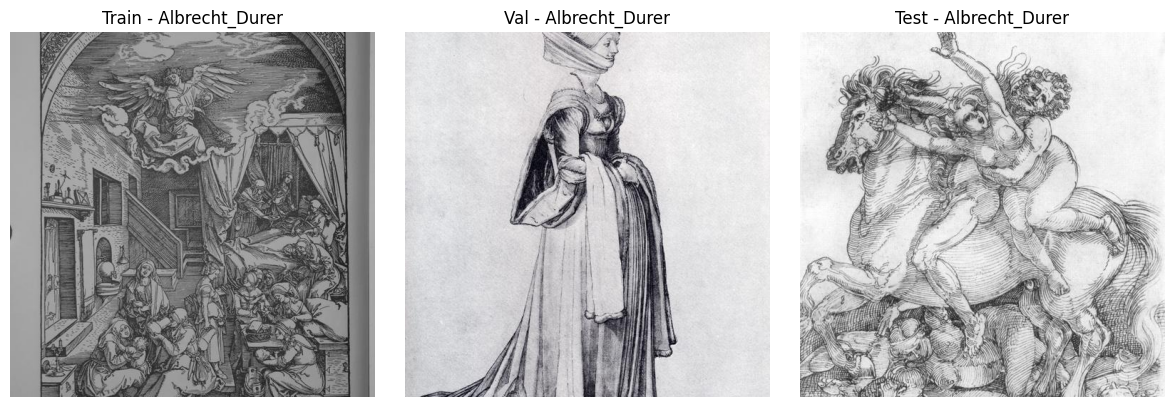

In [24]:
# Quick sanity check: show one sample per split
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, d) in zip(axes, [("Train", train_dir), ("Val", val_dir), ("Test", test_dir)]):
    cls = sorted(os.listdir(d))[0]
    img_path = os.path.join(d, cls, os.listdir(os.path.join(d, cls))[0])
    ax.imshow(plt.imread(img_path))
    ax.set_title(f"{name} - {cls}")
    ax.axis("off")
plt.tight_layout()
plt.show()

Now, to ensure that the data is correctly stratified:

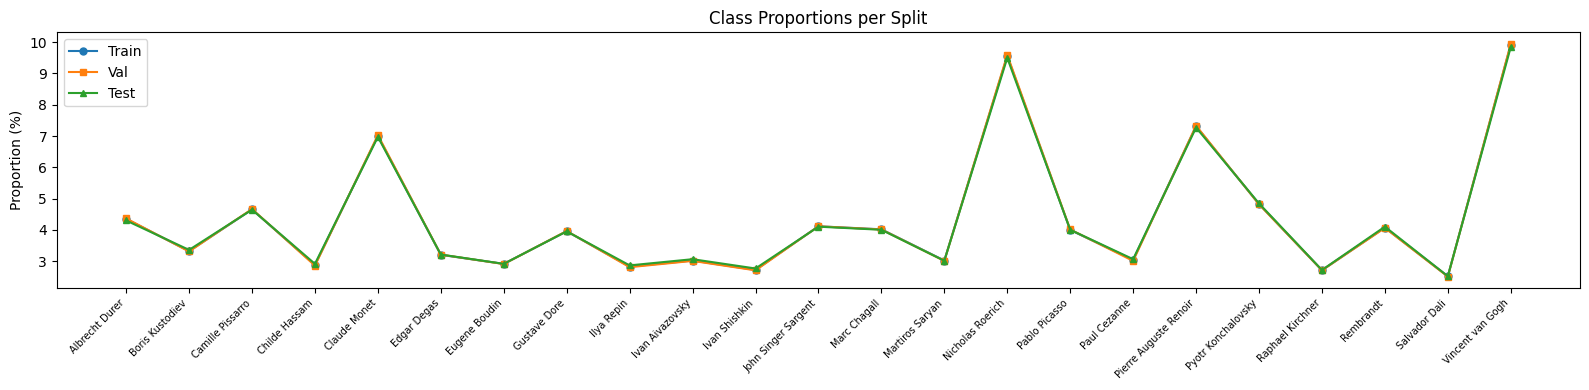

In [25]:
splits_info = {"Train": train_dir, "Val": val_dir, "Test": test_dir}
counts = {}
for name, path in splits_info.items():
    counts[name] = {cls: len(os.listdir(os.path.join(path, cls)))
                    for cls in sorted(os.listdir(path))}

classes = sorted(counts["Train"].keys())
n_classes = len(classes)

fig, ax = plt.subplots(figsize=(16, 4))
for split, marker in zip(["Train", "Val", "Test"], ["o", "s", "^"]):
    vals = np.array([counts[split][c] for c in classes])
    proportions = vals / vals.sum() * 100
    ax.plot(range(n_classes), proportions, marker=marker, label=split, markersize=5)

ax.set_xticks(range(n_classes))
ax.set_xticklabels([c.replace("_", " ") for c in classes], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Proportion (%)")
ax.set_title("Class Proportions per Split")
ax.legend()
plt.tight_layout()
plt.show()

The lines are all overlaped, it means that the stratifying was done correctly.

## 2.2 Class Distribution

This type of datasets often have uneven class distributions. We inspected sample counts per class to detect imbalance that could bias training and justify our use of **F1 score** as the primary metric.

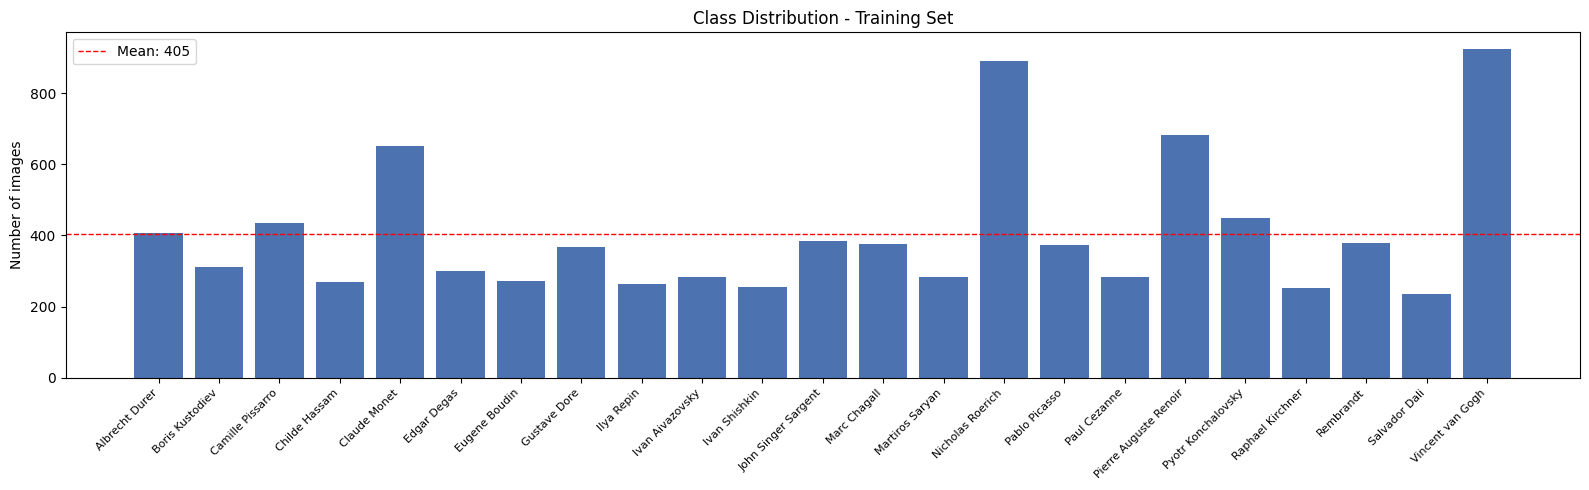

Total: 9326 images, 23 classes
Mean: 405.5 | Median: 369.0 | Std: 192.0
Max: 925 (Vincent_van_Gogh)
Min: 235 (Salvador_Dali)
Imbalance ratio (max/min): 3.9x
Classes below mean: 16 / 23


In [26]:
train_counts = {cls: len(os.listdir(os.path.join(train_dir, cls)))
                for cls in sorted(os.listdir(train_dir))}

classes = list(train_counts.keys())
values = list(train_counts.values())

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(len(classes)), values, color="#4C72B0")
ax.axhline(np.mean(values), color="red", linestyle="--", linewidth=1, label=f"Mean: {np.mean(values):.0f}")
ax.set_xticks(range(len(classes)))
ax.set_xticklabels([c.replace("_", " ") for c in classes], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Number of images")
ax.set_title("Class Distribution - Training Set")
ax.legend()
plt.tight_layout()
plt.show()

# Quantitative summary
values_arr = np.array(values)
print(f"Total: {values_arr.sum()} images, {len(classes)} classes")
print(f"Mean: {values_arr.mean():.1f} | Median: {np.median(values_arr):.1f} | Std: {values_arr.std():.1f}")
print(f"Max: {values_arr.max()} ({classes[values_arr.argmax()]})")
print(f"Min: {values_arr.min()} ({classes[values_arr.argmin()]})")
print(f"Imbalance ratio (max/min): {values_arr.max()/values_arr.min():.1f}x")
print(f"Classes below mean: {(values_arr < values_arr.mean()).sum()} / {len(classes)}")

As expected, the distribution confirms a moderate imbalance (3.9×), with Van Gogh dominating (925 samples) and Dalí as the smallest class (235 samples). 16 of 23 classes fall below the mean (406), meaning the majority of classes are underrepresented. To mitigate this, we apply class weights during training, scaling the loss contribution of minority classes proportionally.

## 2.3 Sample Images per Artist

Here we visualize a few paintings per artist to check image quality, aspect ratio variation, and how visually distinct each artist's style is.

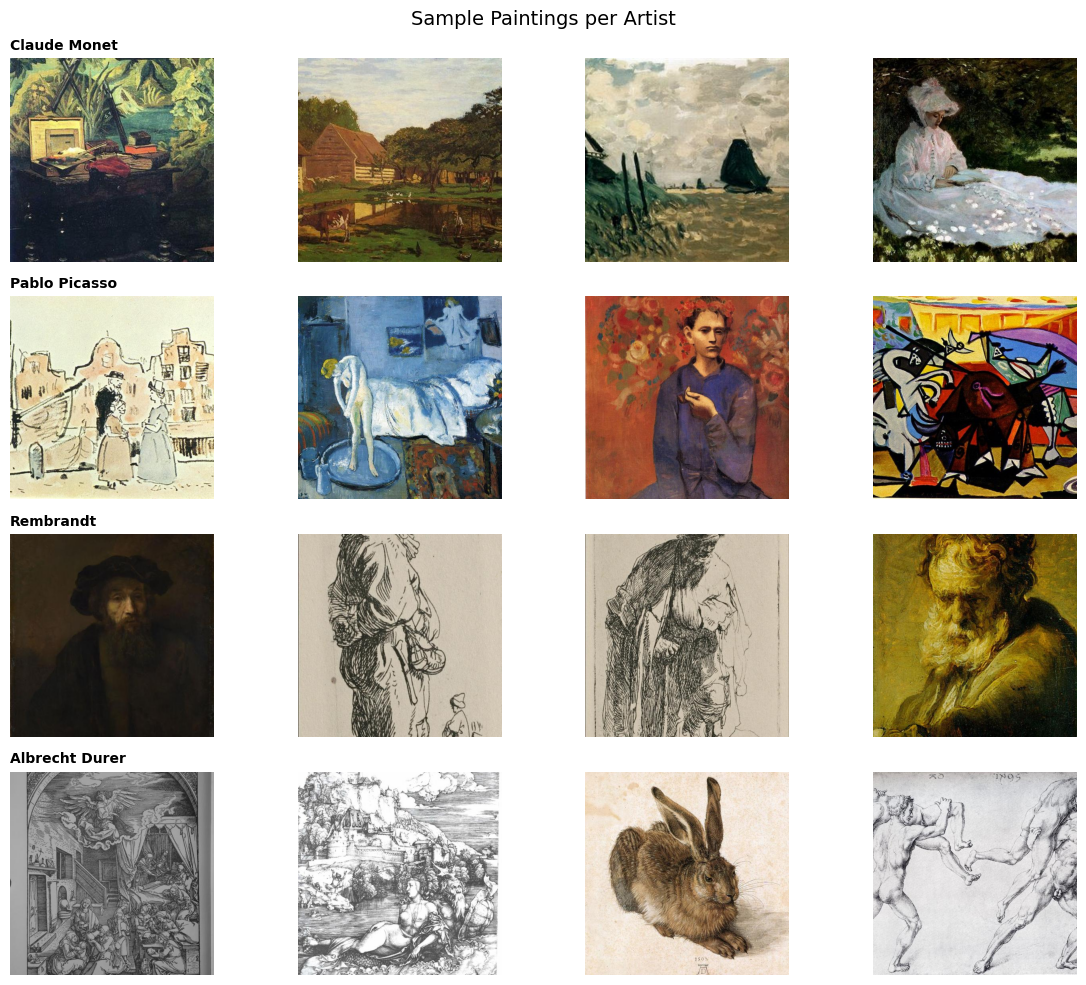

In [27]:
n_samples = 4 # number of samples to show per class
n_display = 4  # number of artists to show
display_classes = ["Claude_Monet", "Pablo_Picasso", "Rembrandt", "Albrecht_Durer"]

fig, axes = plt.subplots(n_display, n_samples, figsize=(12, 10))

for i, cls in enumerate(display_classes):
    cls_path = os.path.join(train_dir, cls)
    imgs = sorted(os.listdir(cls_path))[:n_samples]
    for j in range(n_samples):
        if j < len(imgs):
            img = plt.imread(os.path.join(cls_path, imgs[j]))
            axes[i, j].imshow(img)
        axes[i, j].axis("off")
    axes[i, 0].set_title(cls.replace("_", " "), fontsize=10, loc="left", fontweight="bold")

plt.suptitle("Sample Paintings per Artist", fontsize=14)
plt.tight_layout()
plt.show()

The four selected artists - Dürer, Rembrandt, Monet, and Picasso - show clear differences in texture, palette, and composition. Artists sharing closer historical periods or movements will naturally be harder to separate, which is one of the main challenges of this task.

The goal of this project is precisely to learn these visual distinctions automatically, training a model to attribute a painting to its correct artist from image features alone.

## 2.4 Image Properties

Now we inspect the resolution and aspect ratio of training images to inform our resizing strategy. High variance in dimensions or aspect ratios can introduce distortion when resizing to a fixed input size.

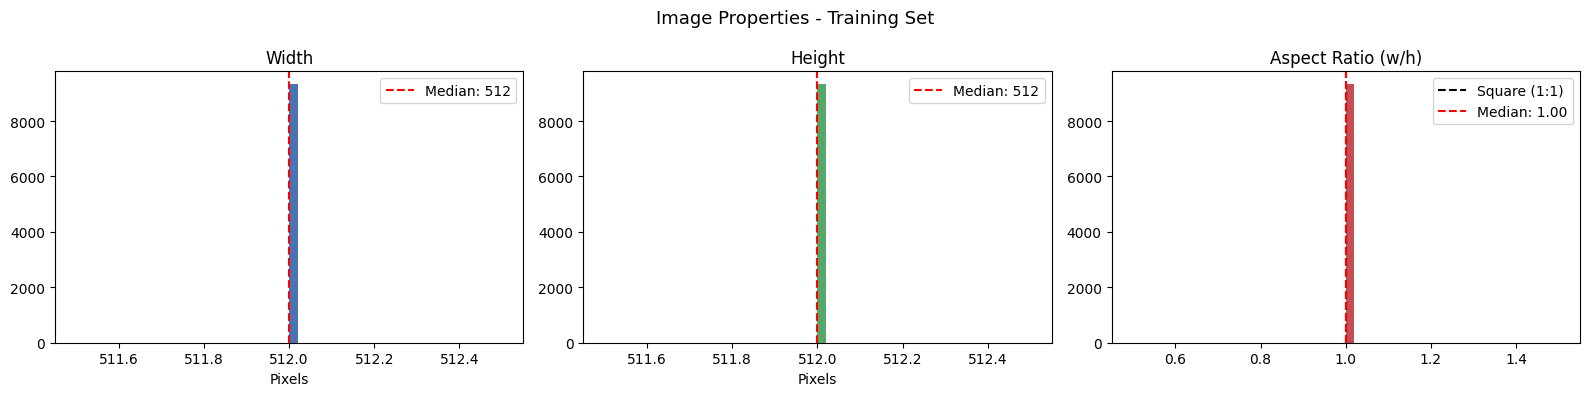

Width  — Median: 512, Mean: 512, Range: [512, 512]
Height — Median: 512, Mean: 512, Range: [512, 512]
Aspect — Median: 1.00, Mean: 1.00, Std: 0.00


In [28]:
widths, heights, aspects = [], [], []
for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        try:
            img = Image.open(os.path.join(cls_path, img_name))
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspects.append(w / h)
        except:
            pass

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(widths, bins=50, color="#4C72B0")
axes[0].axvline(np.median(widths), color="red", linestyle="--", label=f"Median: {np.median(widths):.0f}")
axes[0].set_title("Width")
axes[0].set_xlabel("Pixels")
axes[0].legend()

axes[1].hist(heights, bins=50, color="#55A868")
axes[1].axvline(np.median(heights), color="red", linestyle="--", label=f"Median: {np.median(heights):.0f}")
axes[1].set_title("Height")
axes[1].set_xlabel("Pixels")
axes[1].legend()

axes[2].hist(aspects, bins=50, color="#C44E52")
axes[2].axvline(1.0, color="black", linestyle="--", label="Square (1:1)")
axes[2].axvline(np.median(aspects), color="red", linestyle="--", label=f"Median: {np.median(aspects):.2f}")
axes[2].set_title("Aspect Ratio (w/h)")
axes[2].legend()

plt.suptitle("Image Properties - Training Set", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Width  — Median: {np.median(widths):.0f}, Mean: {np.mean(widths):.0f}, Range: [{min(widths)}, {max(widths)}]")
print(f"Height — Median: {np.median(heights):.0f}, Mean: {np.mean(heights):.0f}, Range: [{min(heights)}, {max(heights)}]")
print(f"Aspect — Median: {np.median(aspects):.2f}, Mean: {np.mean(aspects):.2f}, Std: {np.std(aspects):.2f}")

All training images are uniform at 512×512 pixels with a perfect 1:1 aspect ratio, indicating the dataset was pre-processed beforehand. No distortion is introduced by resizing, and the choice of input resolution is purely a computational trade-off - we resize to 128x128 (FOR NOW!!!) for the sake of our computers, to reduce memory usage and training time on limited hardware.

## 2.5 Corrupted & Non-RGB Images

We now scan all splits for corrupted files and non-RGB images (e.g. grayscale, RGBA). Corrupted files would cause training crashes, and non-RGB images need to be converted to avoid channel mismatch errors.

In [29]:
corrupted = []
non_rgb = []

for split_name, split_dir in [("Train", train_dir), ("Val", val_dir), ("Test", test_dir)]:
    for cls in os.listdir(split_dir):
        cls_path = os.path.join(split_dir, cls)
        for img_name in os.listdir(cls_path):
            path = os.path.join(cls_path, img_name)
            try:
                img = Image.open(path)
                img.verify()
                img = Image.open(path)  # re-open after verify
                if img.mode != "RGB":
                    non_rgb.append((split_name, cls, img_name, img.mode))
            except Exception as e:
                corrupted.append((split_name, cls, img_name, str(e)))

print(f"Corrupted images: {len(corrupted)}")
print(f"Non-RGB images:   {len(non_rgb)}")

if corrupted:
    print("\nCorrupted:")
    for c in corrupted[:10]:
        print(f"  [{c[0]}] {c[1]}/{c[2]} — {c[3]}")

if non_rgb:
    print("\nNon-RGB:")
    for g in non_rgb[:10]:
        print(f"  [{g[0]}] {g[1]}/{g[2]} — mode: {g[3]}")

Corrupted images: 0
Non-RGB images:   0


No corrupted or non-RGB images were found across all splits, the dataset is clean and ready for training without any additional handling.

## 2.6 Pixel Intensity Distribution (RGB)

We sample 5 images per class and inspect the RGB channel distributions to assess whether ImageNet normalization is a reasonable approximation for this dataset. 

ImageNet is a large-scale dataset with ~1.4 million images across 1,000 classes, widely used to pretrain CNN backbones. For readability, statistics are shown in [0,1] scale following the PyTorch convention - in practice, preprocessing is handled by Keras' `vgg16.preprocess_input` (Caffe mode), which subtracts per-channel means in [0,255] scale without std division ([source](https://github.com/keras-team/keras/blob/v3.3.3/keras/src/applications/imagenet_utils.py)).

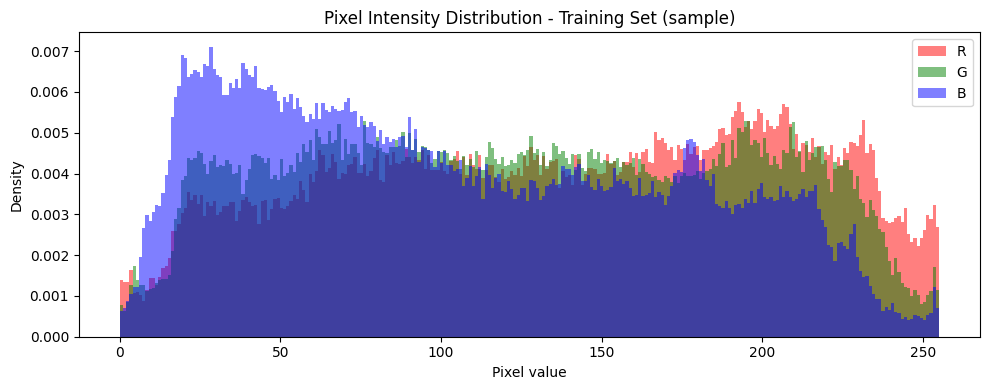

Dataset  - Mean: (0.537, 0.496, 0.419)  Std: (0.266, 0.260, 0.257)
ImageNet - Mean: (0.485, 0.456, 0.406)  Std: (0.229, 0.224, 0.225)


In [30]:
rng = np.random.default_rng(SEED)
r_vals, g_vals, b_vals = [], [], []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    for img_name in sorted(os.listdir(cls_path))[:5]:  # 5 per class
        try:
            img = np.array(Image.open(os.path.join(cls_path, img_name)).convert("RGB").resize((128, 128)))
            # sample 1000 random pixels instead of all - my kernel died when i tried to do all :( 
            pixels = img.reshape(-1, 3)
            idx = rng.choice(len(pixels), size=min(1000, len(pixels)), replace=False)
            pixels = pixels[idx]
            r_vals.extend(pixels[:, 0])
            g_vals.extend(pixels[:, 1])
            b_vals.extend(pixels[:, 2])
        except:
            pass

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(r_vals, bins=256, alpha=0.5, color="red", label="R", density=True)
ax.hist(g_vals, bins=256, alpha=0.5, color="green", label="G", density=True)
ax.hist(b_vals, bins=256, alpha=0.5, color="blue", label="B", density=True)
ax.set_xlabel("Pixel value")
ax.set_ylabel("Density")
ax.set_title("Pixel Intensity Distribution - Training Set (sample)")
ax.legend()
plt.tight_layout()
plt.show()

r_mean, g_mean, b_mean = np.mean(r_vals)/255, np.mean(g_vals)/255, np.mean(b_vals)/255
r_std, g_std, b_std = np.std(r_vals)/255, np.std(g_vals)/255, np.std(b_vals)/255

print(f"Dataset  - Mean: ({r_mean:.3f}, {g_mean:.3f}, {b_mean:.3f})  Std: ({r_std:.3f}, {g_std:.3f}, {b_std:.3f})")
print(f"ImageNet - Mean: (0.485, 0.456, 0.406)  Std: (0.229, 0.224, 0.225)")

The dataset statistics are reasonably close to ImageNet (mean offset < 0.06 per channel, std offset < 0.04), confirming that ImageNet-based normalization is a valid approximation and a valid approach for this problem.

<div id="3-prepro" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    3. Pre Processing
  </h2>
</div>

## 3.1 Data Augmentation

With only ~9,300 images across 23 classes, the model is prone to overfitting. Data augmentation artificially increases the effective training set size by applying random transformations at each epoch, forcing the model to learn more robust and style-invariant features rather than memorizing specific training examples.

(explicar a abordagem)

In [31]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
], name="data_augmentation")

A simple example of how data augmentation deals with our data using that configurations:

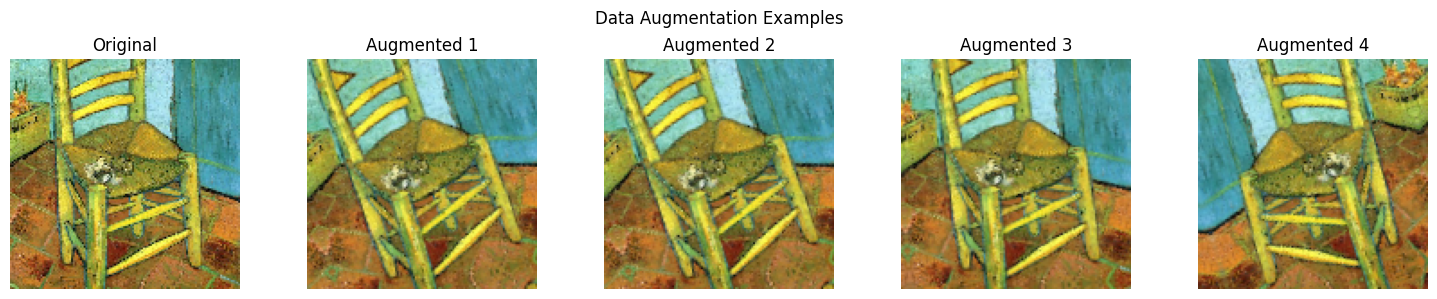

In [32]:
IMG_SIZE = (128, 128)
sample_path = os.path.join(train_dir, "Vincent_van_Gogh", "vincent-van-gogh_van-gogh-s-chair-1889.jpg")
sample_img = tf.keras.utils.load_img(sample_path, target_size=IMG_SIZE)
sample_img = tf.keras.utils.img_to_array(sample_img)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(sample_img.astype("uint8"))
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(1, 5):
    augmented = data_augmentation(tf.expand_dims(sample_img, 0), training=True)
    axes[i].imshow(augmented[0].numpy().astype("uint8"))
    axes[i].set_title(f"Augmented {i}")
    axes[i].axis("off")

plt.suptitle("Data Augmentation Examples")
plt.tight_layout()
plt.show()

The augmented samples confirm that transformations are mild enough to preserve the artist's visual style - Van Gogh's characteristic brushwork and color palette remain clearly identifiable across all variants - while introducing sufficient variation in crop, orientation, and exposure to prevent the model from overfitting to specific image compositions.

## 3.2 Metadata Outliers (from filenames) and painting's year analysis

In [33]:
mismatches = []
years = {}

for cls in sorted(os.listdir(train_dir)):
    cls_path = os.path.join(train_dir, cls)
    cls_years = []
    for img_name in os.listdir(cls_path):
        # Check if artist name in filename matches the folder
        artist_folder = cls.lower().replace("_", "-")
        if not img_name.lower().startswith(artist_folder):
            mismatches.append((cls, img_name))

        # Extract year if present (4-digit number)
        year_match = re.findall(r'(\d{4})', img_name)
        if year_match:
            year = int(year_match[-1])  # last 4-digit number is usually the year
            if 1300 <= year <= 2025:
                cls_years.append(year)

    if cls_years:
        years[cls] = cls_years

print(f"Filename/folder mismatches: {len(mismatches)}")
for m in mismatches[:10]:
    print(f"  Folder: {m[0]} — File: {m[1]}")

print(f"\nYear ranges per artist:")
for cls in sorted(years.keys()):
    y = years[cls]
    print(f"  {cls}: {min(y)}–{max(y)} ({len(y)} paintings with year)")

Filename/folder mismatches: 0

Year ranges per artist:
  Albrecht_Durer: 1489–1528 (207 paintings with year)
  Boris_Kustodiev: 1897–1927 (293 paintings with year)
  Camille_Pissarro: 1856–1903 (327 paintings with year)
  Childe_Hassam: 1885–1921 (21 paintings with year)
  Claude_Monet: 1863–1926 (128 paintings with year)
  Edgar_Degas: 1855–1905 (151 paintings with year)
  Eugene_Boudin: 1850–1897 (150 paintings with year)
  Gustave_Dore: 1852–1882 (28 paintings with year)
  Ilya_Repin: 1859–1926 (220 paintings with year)
  Ivan_Aivazovsky: 1835–1900 (255 paintings with year)
  Ivan_Shishkin: 1854–1898 (176 paintings with year)
  John_Singer_Sargent: 1874–1925 (261 paintings with year)
  Marc_Chagall: 1908–1985 (247 paintings with year)
  Martiros_Saryan: 1898–1972 (274 paintings with year)
  Nicholas_Roerich: 1889–1947 (721 paintings with year)
  Pablo_Picasso: 1893–1971 (333 paintings with year)
  Paul_Cezanne: 1861–1906 (166 paintings with year)
  Pierre_Auguste_Renoir: 1860–1919 (

We verified dataset integrity by cross-checking artist names in filenames against folder labels (0 mismatches found) and extracting painting dates from filenames to confirm they fall within each artist's active period. No labeling anomalies were detected.

In [34]:
formats = []
modes = []
file_sizes = []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        path = os.path.join(cls_path, img_name)
        try:
            file_sizes.append((cls, img_name, os.path.getsize(path)))
            img = Image.open(path)
            formats.append(img.format)
            modes.append(img.mode)
        except:
            pass

print("Image formats:", Counter(formats))
print("Color modes:", Counter(modes))
print(f"\nFile size — Min: {min(f[2] for f in file_sizes)/1024:.1f} KB, "
      f"Max: {max(f[2] for f in file_sizes)/1024:.1f} KB, "
      f"Mean: {np.mean([f[2] for f in file_sizes])/1024:.1f} KB")

# Flag suspiciously small files (< 5 KB)
small = [(f[0], f[1], f[2]/1024) for f in file_sizes if f[2] < 5000]
print(f"\nSuspiciously small files (< 5 KB): {len(small)}")
for s in small:
    print(f"  {s[0]}/{s[1]} — {s[2]:.1f} KB")

Image formats: Counter({'JPEG': 9326})
Color modes: Counter({'RGB': 9326})

File size — Min: 10.7 KB, Max: 133.8 KB, Mean: 55.1 KB

Suspiciously small files (< 5 KB): 0


# Overview

The dataset consists of 13,340 JPEG images (512×512, RGB) across 23 artist classes, with an imbalance ratio of 3.9x (Vincent van Gogh: 925 images vs Salvador Dalí: 235). No corrupted, mislabeled, or anomalous images were found. Per-channel pixel statistics (mean: 0.537, 0.496, 0.419) show a slight shift from ImageNet distributions, consistent with the artistic nature of the paintings.

<div id="4-model" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    4. Model Implementation
  </h2>
</div>

## 4.1 Baseline CNN Model

A minimal Convolutional Neural Network to establish a baseline: (ISTO JA NAO ESTA ASSIM!!! TIVE PREGUIÇA DE MUDAR)
- 3 Conv2D + MaxPooling blocks
- Global Average Pooling → Dense → Softmax (23 classes)
- Images resized to **128 × 128** for fast iteration

In [35]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
NUM_CLASSES = 23

train_ds, val_ds, test_ds, class_names = load_datasets(
    train_dir, val_dir, test_dir,
    img_size=IMG_SIZE, batch_size=BATCH_SIZE,
)


Found 9326 files belonging to 23 classes.
Found 1992 files belonging to 23 classes.
Found 2022 files belonging to 23 classes.
Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


In [36]:
# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

def residual_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding="same", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding="same")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = layers.Rescaling(1.0 / 255)(inputs)

x = residual_block(x, 32)
x = layers.MaxPooling2D()(x)

x = residual_block(x, 64)
x = layers.MaxPooling2D()(x)

x = residual_block(x, 128)
x = layers.MaxPooling2D()(x)

x = residual_block(x, 256)
x = layers.MaxPooling2D()(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="cnn_residual_v5")

### Training

In [37]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=7, restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath="models_results/scratch/scratch_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_stop, reduce_lr, checkpoint_callback],
)

Epoch 1/100


I0000 00:00:1775053292.145910    1992 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_156559__.146


 70/292 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - accuracy: 0.1108 - f1_macro: 0.0767 - loss: 3.7198

I0000 00:00:1775053307.614646    1993 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_156559__.146


292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.1720 - f1_macro: 0.1259 - loss: 3.1930
Epoch 1: val_loss improved from None to 3.90839, saving model to models_results/scratch/scratch_best.keras

Epoch 1: finished saving model to models_results/scratch/scratch_best.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 59s 129ms/step - accuracy: 0.2228 - f1_macro: 0.1671 - loss: 2.8657 - val_accuracy: 0.0316 - val_f1_macro: 0.0050 - val_loss: 3.9084 - learning_rate: 1.0000e-04
Epoch 2/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.2970 - f1_macro: 0.2318 - loss: 2.5028
Epoch 2: val_loss improved from 3.90839 to 2.37307, saving model to models_results/scratch/scratch_best.keras

Epoch 2: finished saving model to models_results/scratch/scratch_best.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 31s 106ms/step - accuracy: 0.3087 - f1_macro: 0.2502 - loss: 2.4532 - val_accuracy: 0.3424 - val_f1_macro: 0.2858 - val_loss: 2.3731 - learning_rate: 1.0000e-04
Epoch 3/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 95

### Learning Curves

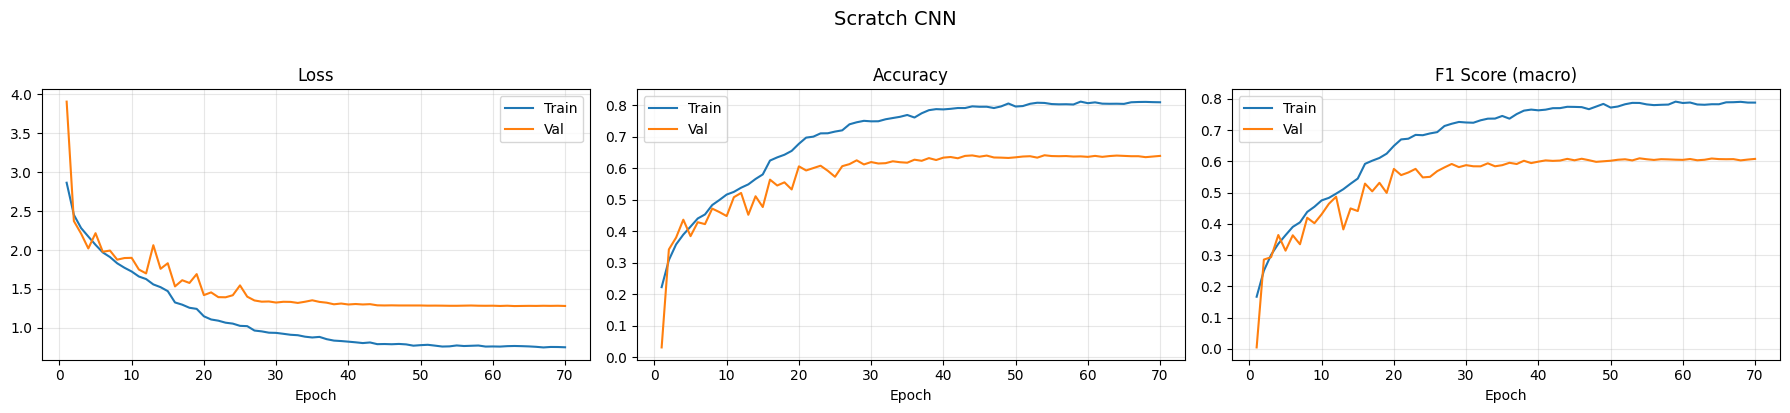

Best epoch (lowest val_loss): 63
  Val Loss: 1.2802
  Val Acc:  0.6386
  Val F1:   0.6049


In [38]:
plot_learning_curves(history, title="Scratch CNN")

### Test Evaluation


  Scratch CNN - Test Evaluation
  Test Loss:     1.2592
  Test Accuracy: 0.6489
  Test F1 Macro: 0.6232

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.70      0.75      0.72        87
      Boris_Kustodiev       0.51      0.38      0.44        68
     Camille_Pissarro       0.59      0.61      0.60        94
        Childe_Hassam       0.57      0.44      0.50        59
         Claude_Monet       0.63      0.72      0.67       141
          Edgar_Degas       0.54      0.48      0.51        65
        Eugene_Boudin       0.72      0.64      0.68        59
         Gustave_Dore       0.84      0.94      0.89        80
           Ilya_Repin       0.51      0.47      0.49        58
      Ivan_Aivazovsky       0.78      0.81      0.79        62
        Ivan_Shishkin       0.67      0.64      0.65        56
  John_Singer_Sargent       0.62      0.73      0.67        83
         Marc_Chagall       0.63      0.60      0.6

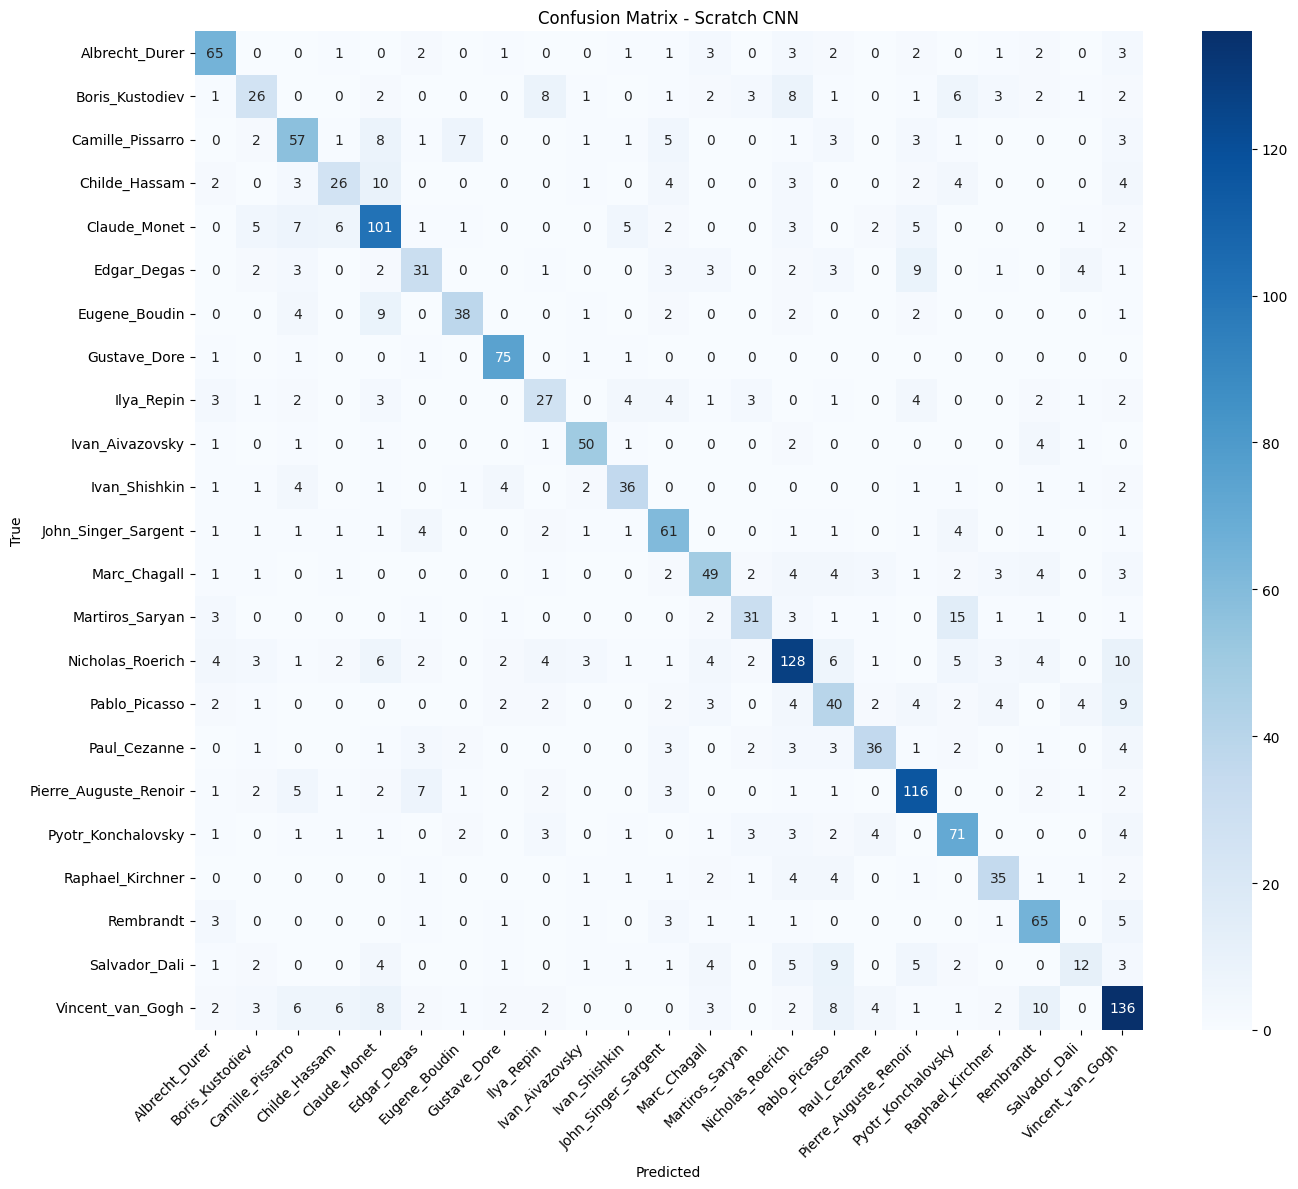

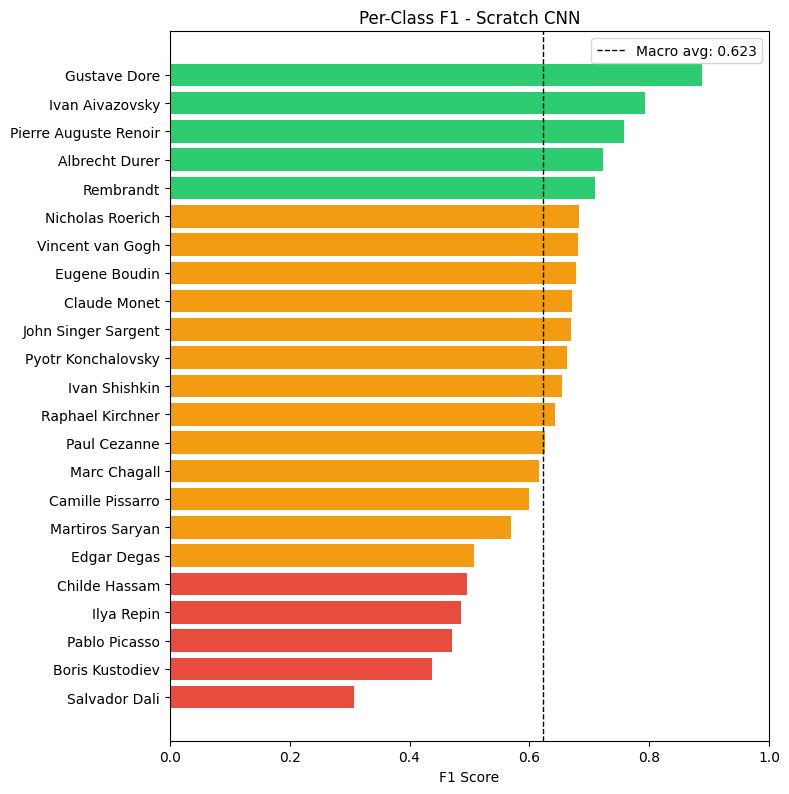

In [39]:
metrics_cnn = evaluate_model(model, test_ds, class_names, "Scratch CNN")

In [40]:
save_history(history, "models_results/scratch/scratch_history.json")

History saved to models_results/scratch/scratch_history.json
